# Simulation of Vessel Trajectories & Anomalies

Use the config file to adjust the number of vessels, obstacles, speed limits, ...

In [1]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=config["num_ships"],
        max_speed_range=config["max_speed_range"],
        speed_variation=config["speed_variation"],
        directional_variation=config["directional_variation"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=config["obstacles"],
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"]
    )

for type, agents in model.agents_by_type.items():
    print(f'{type}: {len(agents)}')

for ship in model.agents.select(agent_type=Ship):
    print(f"Ship {ship.unique_id} has a maximum speed of {ship.original_max_speed}.")

<class 'agents.obstacle.Obstacle'>: 3
<class 'agents.port.Port'>: 10
<class 'agents.ship.Ship'>: 40
Ship 0 has a maximum speed of 3.0999888089679475.
Ship 1 has a maximum speed of 5.735779480438022.
Ship 2 has a maximum speed of 3.4968082983048934.
Ship 3 has a maximum speed of 5.934034947404663.
Ship 4 has a maximum speed of 11.707165178557657.
Ship 5 has a maximum speed of 6.296969651751693.
Ship 6 has a maximum speed of 5.366958307971036.
Ship 7 has a maximum speed of 9.650828603182488.
Ship 8 has a maximum speed of 3.1102165393506964.
Ship 9 has a maximum speed of 8.67265387882884.
Ship 10 has a maximum speed of 4.732146816139919.
Ship 11 has a maximum speed of 6.53836700207464.
Ship 12 has a maximum speed of 11.164694454736.
Ship 13 has a maximum speed of 8.485526566197594.
Ship 14 has a maximum speed of 3.041520151709923.
Ship 15 has a maximum speed of 9.377647391871784.
Ship 16 has a maximum speed of 9.017588123587776.
Ship 17 has a maximum speed of 9.772740277872684.
Ship 18 ha

## Trajectory Simulation

In [2]:
t0 = datetime.now()
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
t1 = datetime.now()
print(f"{datetime.now()} Finished in {t1-t0}.")

2025-09-02 13:00:17.174345 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
Steps 400 - 449...
Steps 450 - 499...
Steps 500 - 549...
Steps 550 - 599...
Steps 600 - 649...
Steps 650 - 699...
Steps 700 - 749...
Steps 750 - 799...
Steps 800 - 849...
Steps 850 - 899...
Steps 900 - 949...
Steps 950 - 999...
Steps 1000 - 1049...
Steps 1050 - 1099...
Steps 1100 - 1149...
Steps 1150 - 1199...
Steps 1200 - 1249...
Steps 1250 - 1299...
Steps 1300 - 1349...
Steps 1350 - 1399...
Steps 1400 - 1449...
Steps 1450 - 1499...
2025-09-02 13:41:15.443970 Finished in 0:40:58.269601.


In [3]:
model.datacollector.get_agent_vars_dataframe()

x  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.port.Port object at 0x7fcfae30c100>                NaN   
     <agents.port.Port object at 0x7fcfae30c220>                NaN   
...                                                             ...   
1500 <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.port.Port object at 0x7fcfae30c460>                NaN   
     10                                                   33.094306   
     3                                                   230.090344   
     23                                                   56.543934   

                                                                  y  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.port.Port object at 0x7fcfae30c100>                NaN   
     <agents.port.Port object at 0x7fcfae30c220>                NaN   
...                                                             ...   
1500 <agents.obstacle.Obstacle object at 0x7fcfae2fd...         NaN   
     <agents.port.Port object at 0x7fcfae30c460>                NaN   
     10                                                   78.120141   
     3                                                   168.908915   
     23                                                   86.261296   

                                                                                                 AStarPath  
Step AgentID                                                                                                
0    <agents.obstacle.Obstacle object at 0x7fcfae2fd...                                               None  
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...                                               None  
     <agents.obstacle.Obstacle object at 0x7fcfae2fd...                                               None  
     <agents.port.Port object at 0x7fcfae30c100>                                                      None  
     <agents.port.Port object at 0x7fcfae30c220>                                                      None  
...                                                                                                    ...  
1500 <agents.obstacle.Obstacle object at 0x7fcfae2fd...                                               None  
     <agents.port.Port object at 0x7fcfae30c460>                                                      None  
     10                                                  [(310, 95), (309, 94), (309, 93), (308, 92), (...  
     3                                                   [(7, 15), (8, 16), (8, 17), (8, 18), (8, 19), ...  
     23                                                  [(7, 15), (8, 16), (8, 17), (8, 18), (8, 19), ...  

[79553 rows x 3 columns]

In [4]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,230.953287,169.747928,"[(230, 169), (229, 168), (228, 167), (227, 166..."
1,0,1,120.255984,24.247715,"[(120, 24), (120, 25), (120, 26), (120, 27), (..."
2,0,2,166.253584,154.756305,"[(166, 154), (166, 153), (166, 152), (166, 151..."
3,0,3,7.214540,15.908203,"[(7, 15), (8, 16), (8, 17), (8, 18), (8, 19), ..."
4,0,5,230.953287,169.747928,"[(230, 169), (230, 168), (230, 167), (230, 166..."
...,...,...,...,...,...
49528,1500,28,309.845319,95.015396,"[(250, 90), (250, 89), (250, 88), (250, 87), (..."
49529,1500,27,250.077741,89.833537,"[(166, 154), (167, 153), (167, 152), (167, 151..."
49530,1500,10,33.094306,78.120141,"[(310, 95), (309, 94), (309, 93), (308, 92), (..."
49531,1500,3,230.090344,168.908915,"[(7, 15), (8, 16), (8, 17), (8, 18), (8, 19), ..."


Saved simulation plot to simulation_plot.png


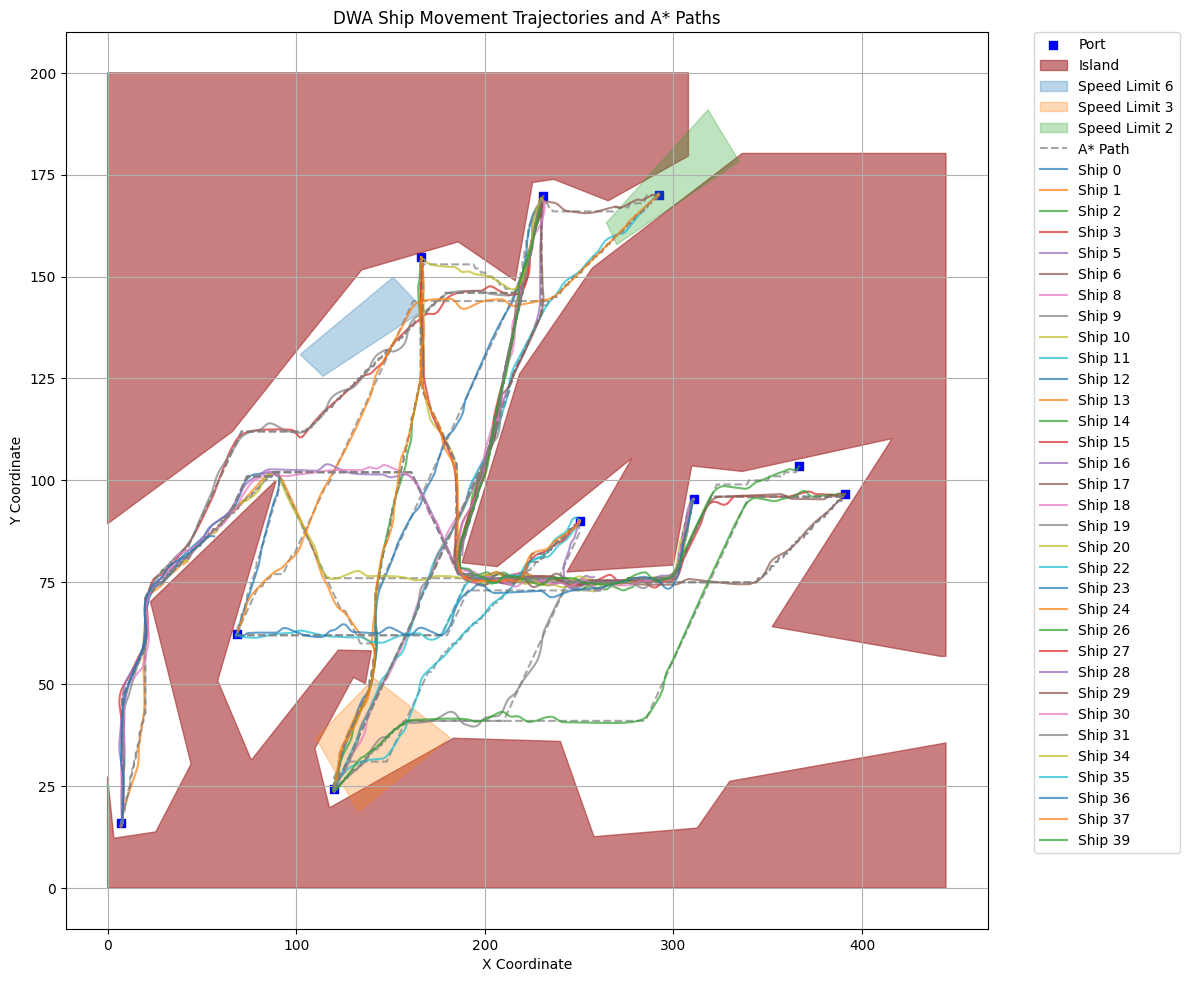

In [5]:
from visualization import plot_simulation

# Run visualization
plot_simulation(df, config)

### Transform Grid to Real-World coordinates

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


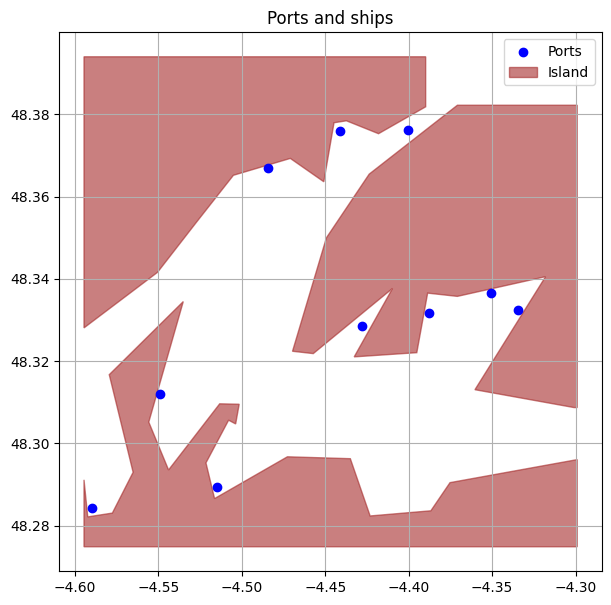

In [6]:
import movingpandas as mpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

start_datetime = datetime.now()
#df = df.drop('AStarPath', axis=1)

def map_to_geocoords(x, y, bounds, width, height):
    lon = bounds["min_lon"] + (x / width) * (bounds["max_lon"] - bounds["min_lon"])
    lat = bounds["min_lat"] + (y / height) * (bounds["max_lat"] - bounds["min_lat"])
    return lon, lat

df[["x", "y"]] = df.apply(
    lambda row: map_to_geocoords(row["x"], row["y"], config["geospatial_bounds"], config["width"], config["height"]),
    axis=1, result_type="expand"
)

time_step_seconds = config["time_step_seconds"]
start_datetime = datetime.now()

df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step * time_step_seconds))

tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

fig, ax = plt.subplots(figsize=(7,7))

# Transform and plot ports
geo_ports = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in config["ports"]]
x_coords, y_coords = zip(*geo_ports)
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

# Transform and plot obstacles
for island in config["obstacles"]:
    geo_island = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in island]
    island_shape = Polygon(geo_island)
    x, y = island_shape.exterior.xy
    ax.fill(x,y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")

#tc.plot(ax=ax, label='Ship trajectories', column='speed', legend=True)
ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()


In [7]:
import movingpandas as mpd

start_datetime = datetime.now()
df = df.drop('AStarPath', axis=1, errors='ignore'
)
df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

In [8]:
#tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)
tc

TrajectoryCollection with 33 trajectories

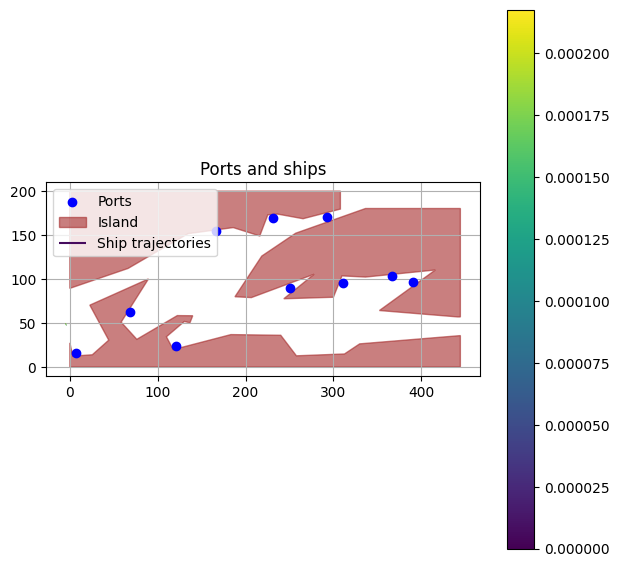

In [9]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

fig, ax = plt.subplots(figsize=(7,7))

x_coords, y_coords = zip(*config["ports"])
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

for island in config["obstacles"]:
    island_shape = Polygon(island)
    x, y = island_shape.exterior.xy
    ax.fill(x, y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")

tc.plot(ax=ax, label='Ship trajectories', column='speed', legend=True)
ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()

In [10]:
try:
    tc.trajectories[0].hvplot()
except:
    pass

In [11]:
import os

tc.add_speed(overwrite=True, n_threads=os.cpu_count())
tc.trajectories[0].df#.hvplot(c='speed')

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Miss

,Step,AgentID,geometry,speed
t,,,,
2025-09-02 13:42:17.955294,0,0,POINT (-4.441 48.376),0.000006
2025-09-02 13:42:18.955294,1,0,POINT (-4.441 48.376),0.000006
2025-09-02 13:42:19.955294,2,0,POINT (-4.441 48.376),0.000007
2025-09-02 13:42:20.955294,3,0,POINT (-4.441 48.376),0.000008
2025-09-02 13:42:21.955294,4,0,POINT (-4.441 48.376),0.000008
...,...,...,...,...
2025-09-02 14:07:13.955294,1496,0,POINT (-4.515 48.289),0.000006
2025-09-02 14:07:14.955294,1497,0,POINT (-4.515 48.289),0.000006
2025-09-02 14:07:15.955294,1498,0,POINT (-4.515 48.289),0.000006


In [12]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')
sim_result#[sim_result['speed'] > 0.6]

Saved simulation results to sim_20250902_134304.csv


,Step,AgentID,geometry,speed,x,y
t,,,,,,
2025-09-02 13:42:17.955294,0,0,POINT (-4.441 48.376),0.000006,-4.440987,48.375958
2025-09-02 13:42:18.955294,1,0,POINT (-4.441 48.376),0.000006,-4.440992,48.375954
2025-09-02 13:42:19.955294,2,0,POINT (-4.441 48.376),0.000007,-4.440997,48.375950
2025-09-02 13:42:20.955294,3,0,POINT (-4.441 48.376),0.000008,-4.441003,48.375945
2025-09-02 13:42:21.955294,4,0,POINT (-4.441 48.376),0.000008,-4.441010,48.375940
...,...,...,...,...,...,...
2025-09-02 14:07:13.955294,1496,39,POINT (-4.442 48.374),0.000095,-4.442361,48.373812
2025-09-02 14:07:14.955294,1497,39,POINT (-4.442 48.374),0.000096,-4.442322,48.373899
2025-09-02 14:07:15.955294,1498,39,POINT (-4.442 48.374),0.000097,-4.442283,48.373988


## Anomaly Simulation

In [13]:
import numpy as np
import pandas as pd
import movingpandas as mpd
from datetime import datetime, timedelta

In [19]:
sim_out_file_name = 'sim_20250902_134304.csv'
PERCENTAGE_OF_ANOMALIES = 0.05

In [20]:
sims = pd.read_csv(sim_out_file_name)
sims

,t,Step,AgentID,geometry,speed,x,y
0,2025-09-02 13:42:17.955294,0,0,POINT (-4.440986813377944 48.37595799683991),0.000006,-4.440987,48.375958
1,2025-09-02 13:42:18.955294,1,0,POINT (-4.440991769509718 48.375954024767985),0.000006,-4.440992,48.375954
2,2025-09-02 13:42:19.955294,2,0,POINT (-4.440997221254668 48.37594965548887),0.000007,-4.440997,48.375950
3,2025-09-02 13:42:20.955294,3,0,POINT (-4.441003168612797 48.375944889002554),0.000008,-4.441003,48.375945
4,2025-09-02 13:42:21.955294,4,0,POINT (-4.441009611584103 48.37593972530905),0.000008,-4.441010,48.375940
...,...,...,...,...,...,...,...
49528,2025-09-02 14:07:13.955294,1496,39,POINT (-4.442361467790267 48.37381152325975),0.000095,-4.442361,48.373812
49529,2025-09-02 14:07:14.955294,1497,39,POINT (-4.442322480817467 48.37389934051111),0.000096,-4.442322,48.373899
49530,2025-09-02 14:07:15.955294,1498,39,POINT (-4.442283248114587 48.373987711263766),0.000097,-4.442283,48.373988
49531,2025-09-02 14:07:16.955294,1499,39,POINT (-4.442243769681629 48.374076635517724),0.000097,-4.442244,48.374077


In [21]:
#sims = sims[sims.AgentID<29].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'


In [22]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import movingpandas as mpd

# Assure-toi que 't' est bien en datetime
sims = sims.copy()
sims['t'] = pd.to_datetime(sims['t'])

# 1) Créer la colonne geometry à partir de x,y
sims_gdf = gpd.GeoDataFrame(
    sims,
    geometry=gpd.points_from_xy(sims['x'], sims['y']),
    crs=31287   # Maintenant OK, car geometry est définie
)

# 2) Trier par AgentID et temps (bonnes pratiques)
sims_gdf = sims_gdf.sort_values(['AgentID', 't'])

# 3) Créer la TrajectoryCollection (plus besoin de x,y ici)
tc = mpd.TrajectoryCollection(sims_gdf, traj_id_col='AgentID', t='t')


tc

TrajectoryCollection with 33 trajectories

In [23]:
# Remove stopped segments (with speed < 0.0001)
tc = mpd.SpeedSplitter(tc).split(speed=0.0001, duration=timedelta(seconds=5))
tc

TrajectoryCollection with 94 trajectories

### Speed

Change the timestamps to make a subsection of the trajectory faster

In [24]:
unique_ids = sims.AgentID.unique()
unique_ids

array([ 0,  1,  2,  3,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 22, 23, 24, 26, 27, 28, 29, 30, 31, 34, 35, 36, 37, 39])

In [25]:
sample_ids_pd = pd.Series(unique_ids).sample(frac=PERCENTAGE_OF_ANOMALIES).tolist()
print("Subset we'll insert anomalies in: ", sample_ids_pd)

Subset we'll insert anomalies in:  [31, 16]


In [26]:
def inject_speed_anomaly(traj, duration_pct=(0.1,0.2), speedup_pct=(1.5,2.5)):
    df = traj.df.copy()
    df.reset_index(inplace=True)
    df["t_diff"] = df['t'].diff()
    # Choose within middle range
    total_steps = len(df)
    anomaly_start_idx = np.random.randint(0.1 * total_steps, 0.8 * total_steps)  
    duration_pct = duration_pct[0] + (np.random.random() * (duration_pct[1]-duration_pct[0]))
    anomaly_duration = int(duration_pct * total_steps)  
    # Insert new values
    speedup_pct = speedup_pct[0] + (np.random.random() * (speedup_pct[1]-speedup_pct[0]))
    new_vals = df.iloc[anomaly_start_idx : anomaly_start_idx + anomaly_duration].t_diff / speedup_pct
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "t_diff"] = new_vals
    # Flag anomalies
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "is_anomaly"] = True
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "anomaly_type"] = 'speed'

    # Correct the timestamp update logic
    df["t"] = df["t"].iloc[0] + df["t_diff"].fillna(pd.Timedelta(seconds=0)).cumsum()
    return mpd.Trajectory(df,t='t',traj_id=traj.id)

<Axes: >

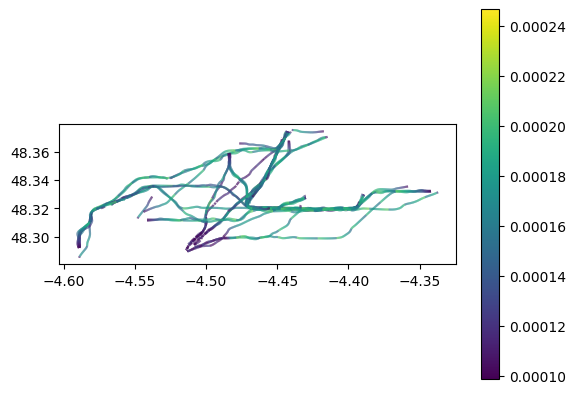

In [27]:
for i, traj in enumerate(tc.trajectories):
    if i in sample_ids_pd: 
        traj = inject_speed_anomaly(traj)
        tc.trajectories[i] = traj
    
tc.add_speed(overwrite=True)
tc.plot(column='speed', legend=True)

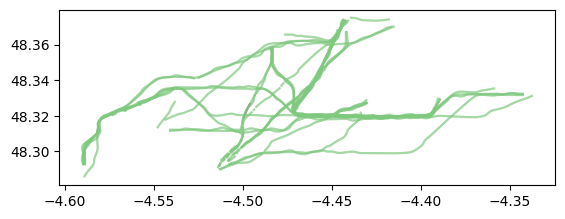

In [28]:
ax = tc.plot(column='is_anomaly', cmap='Accent')

In [29]:
try:
    tc.trajectories[0].hvplot(c='speed')
except:
    pass

In [30]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_speed_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulated speed anomalies to {sim_out_file_name}')

Saved simulated speed anomalies to anomalies_speed_20250902_134524.csv


### Location

#### Generate trajectories that pass through obstacles

Note that is not guaranteed that each resulting trajectory will pass through an obtacle! Ships simply ignore the obstacles.

In [31]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=int(config["num_ships"]*2*PERCENTAGE_OF_ANOMALIES), # doubling the number, assuming that 50% will violate obstacles
        max_speed_range=config["max_speed_range"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=[config["obstacles"][0]], # Here we only select the first obstacle that describes the main land mass
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"],
        speed_variation=config.get("speed_variation", 0.1),           # 
        directional_variation=config.get("directional_variation", 5)  #
    )

In [32]:
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
print(f"{datetime.now()} Finished.")

2025-09-02 13:45:44.771614 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
Steps 400 - 449...
Steps 450 - 499...
Steps 500 - 549...
Steps 550 - 599...
Steps 600 - 649...
Steps 650 - 699...
Steps 700 - 749...
Steps 750 - 799...
Steps 800 - 849...
Steps 850 - 899...
Steps 900 - 949...
Steps 950 - 999...
Steps 1000 - 1049...
Steps 1050 - 1099...
Steps 1100 - 1149...
Steps 1150 - 1199...
Steps 1200 - 1249...
Steps 1250 - 1299...
Steps 1300 - 1349...
Steps 1350 - 1399...
Steps 1400 - 1449...
Steps 1450 - 1499...
2025-09-02 13:48:13.657139 Finished.


In [33]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,250.195753,90.029012,"[(250, 90), (251, 91), (251, 92), (252, 93), (..."
1,0,1,68.573166,62.428321,"[(68, 62), (69, 62), (70, 62), (71, 62), (72, ..."
2,0,2,7.214540,15.908203,"[(7, 15), (8, 16), (9, 17), (10, 18), (11, 19)..."
3,0,3,250.195753,90.029012,"[(250, 90), (251, 91), (251, 92), (252, 93), (..."
4,1,2,7.224473,15.909363,"[(7, 15), (8, 16), (9, 17), (10, 18), (11, 19)..."
...,...,...,...,...,...
5999,1499,3,292.223319,170.118267,"[(250, 90), (251, 91), (251, 92), (252, 93), (..."
6000,1500,2,67.869685,62.217851,"[(7, 15), (8, 16), (9, 17), (10, 18), (11, 19)..."
6001,1500,1,366.256505,102.830168,"[(68, 62), (69, 62), (70, 62), (71, 62), (72, ..."
6002,1500,3,292.231020,170.111888,"[(250, 90), (251, 91), (251, 92), (252, 93), (..."


Saved simulation plot to simulation_plot.png


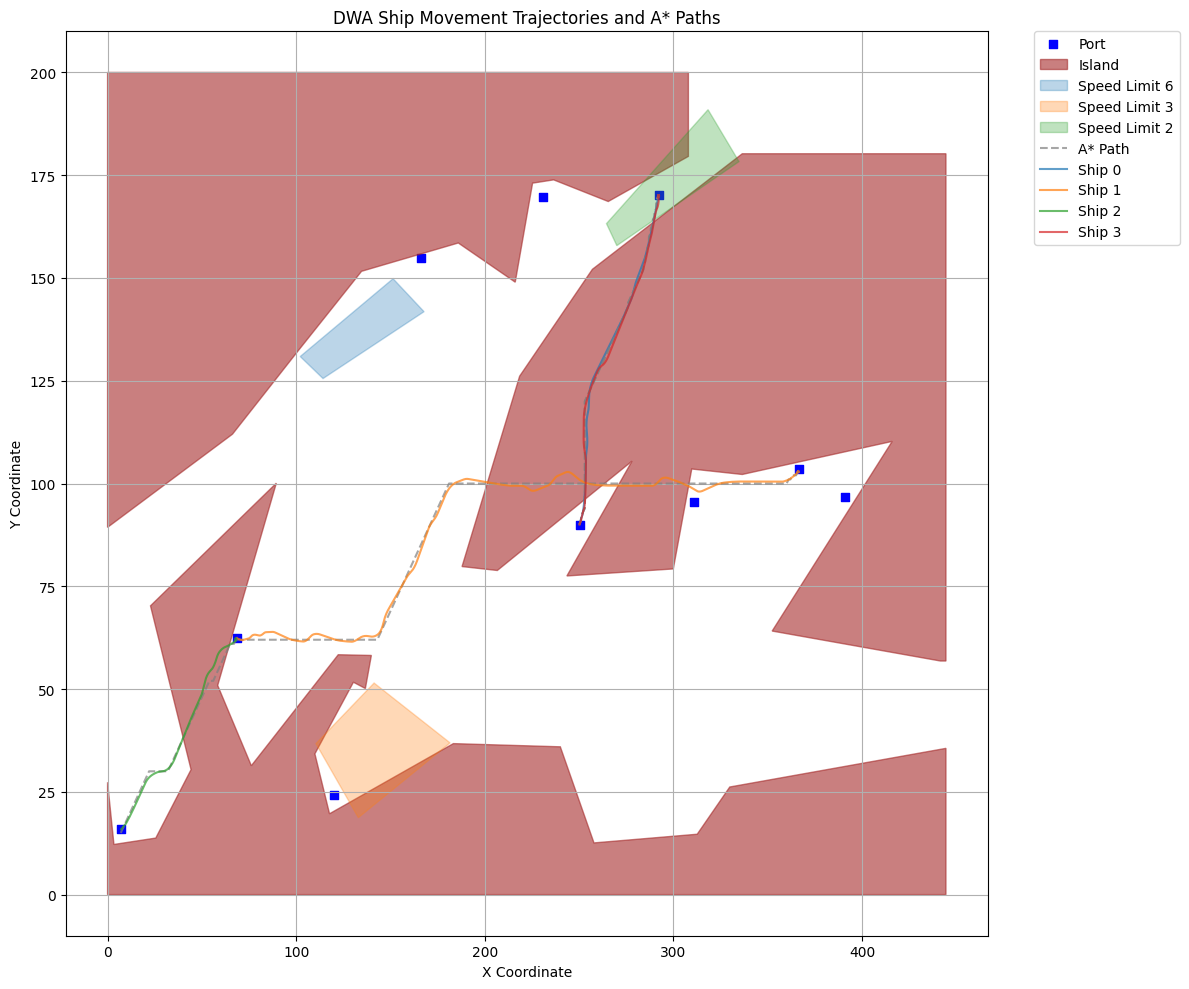

In [34]:
from visualization import plot_simulation
plot_simulation(df, config)

In [35]:
import movingpandas as mpd

start_datetime = datetime.now()
df = df.drop('AStarPath', axis=1)
df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

In [36]:
tc.add_speed(overwrite=True)
tc.trajectories[0].df

,Step,AgentID,geometry,speed
t,,,,
2025-09-02 13:48:57.984431,0,0,POINT (250.196 90.029),0.010
2025-09-02 13:48:58.984431,1,0,POINT (250.202 90.037),0.010
2025-09-02 13:48:59.984431,2,0,POINT (250.209 90.045),0.011
2025-09-02 13:49:00.984431,3,0,POINT (250.216 90.055),0.012
2025-09-02 13:49:01.984431,4,0,POINT (250.224 90.065),0.013
...,...,...,...,...
2025-09-02 14:13:53.984431,1496,0,POINT (291.98 169.744),0.010
2025-09-02 14:13:54.984431,1497,0,POINT (291.971 169.748),0.010
2025-09-02 14:13:55.984431,1498,0,POINT (291.962 169.754),0.010


In [37]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_no-obstacles_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')

Saved simulation results to sim_no-obstacles_20250902_134909.csv


#### Flag anomalies

In [38]:
sims = pd.read_csv(sim_out_file_name)
sims

,t,Step,AgentID,geometry,speed,x,y
0,2025-09-02 13:48:57.984431,0,0,POINT (250.19575278361827 90.02901168407732),0.010,250.195753,90.029012
1,2025-09-02 13:48:58.984431,1,0,POINT (250.20213161735433 90.03671301384352),0.010,250.202132,90.036713
2,2025-09-02 13:48:59.984431,2,0,POINT (250.20892417296795 90.04536524986872),0.011,250.208924,90.045365
3,2025-09-02 13:49:00.984431,3,0,POINT (250.21633423363738 90.05480405280531),0.012,250.216334,90.054804
4,2025-09-02 13:49:01.984431,4,0,POINT (250.22436179936258 90.06502942265327),0.013,250.224362,90.065029
...,...,...,...,...,...,...,...
5999,2025-09-02 14:13:53.984431,1496,3,POINT (292.1983639495931 170.13486838835678),0.010,292.198364,170.134868
6000,2025-09-02 14:13:54.984431,1497,3,POINT (292.20696833265333 170.12977284205118),0.010,292.206968,170.129773
6001,2025-09-02 14:13:55.984431,1498,3,POINT (292.21529424341713 170.12423396039935),0.010,292.215294,170.124234
6002,2025-09-02 14:13:56.984431,1499,3,POINT (292.2233188611418 170.1182669250909),0.010,292.223319,170.118267


In [39]:
#sims = sims[sims.AgentID<22].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'
sims["geometry"] = [Point(xy) for xy in zip(sims["x"], sims["y"])]

tc = mpd.TrajectoryCollection(sims, t='t', traj_id_col='AgentID', x='x', y='y', crs=4326)
tc

TrajectoryCollection with 4 trajectories

<Axes: >

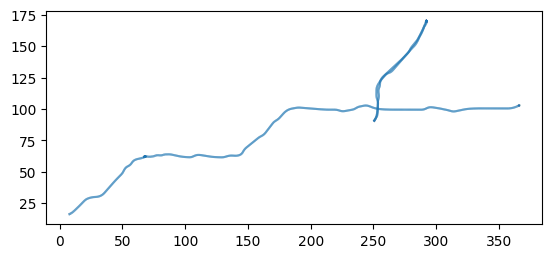

In [49]:
tc.plot(aspect="equal")

In [50]:
from shapely.geometry import Polygon
from geopandas import GeoSeries

def inject_location_anomaly(traj, polygon):
    df = traj.df.copy()
    intersecting = df.intersects(polygon)
    df.loc[intersecting, 'is_anomaly'] = True
    df.loc[intersecting, 'anomaly_type'] = 'location'
    return mpd.Trajectory(df,t='t',traj_id=traj.id)

In [51]:

obstacles=config["obstacles"]
polygons=[]

for obstacle in obstacles:
    polygon = Polygon(obstacle)
    polygons.append(polygon)
    for i, traj in enumerate(tc.trajectories):
        traj = inject_location_anomaly(traj, polygon)
        tc.trajectories[i] = traj
    

<Axes: >

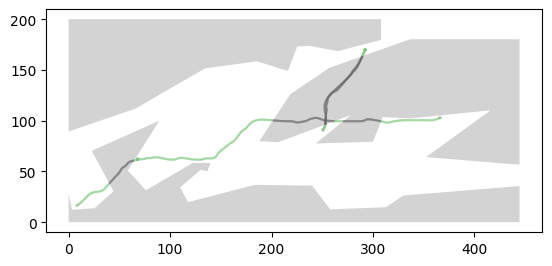

In [53]:
ax = tc.plot(column='is_anomaly', cmap='Accent', aspect="equal")
GeoSeries(polygons).plot(ax=ax, color="lightgray")

In [54]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_loc_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulated location anomalies to {sim_out_file_name}')

Saved simulated location anomalies to anomalies_loc_20250902_140555.csv


### Direction

TODO

## Merge files

In [55]:
df1 = pd.read_csv("anomalies_speed_20250902_134524.csv")
df2 = pd.read_csv("anomalies_loc_20250902_140555.csv")
out = pd.concat([df1,df2])[['t','AgentID','speed','is_anomaly','anomaly_type','x','y']]
out.to_csv("synthetic_vessel_tracks_with_anomalies_20250517.csv", index=False)

In [56]:
tmp = pd.read_csv("synthetic_vessel_tracks_with_anomalies_20250517.csv")
tmp

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
0,2025-09-02 13:44:55.955294000,0_0,0.000101,False,NaN,-4.446596,48.369605
1,2025-09-02 13:44:56.955294000,0_0,0.000101,False,NaN,-4.446619,48.369507
2,2025-09-02 13:45:04.955294000,0_1,0.000101,False,NaN,-4.446722,48.368729
3,2025-09-02 13:45:05.955294000,0_1,0.000101,False,NaN,-4.446731,48.368629
4,2025-09-02 13:45:06.955294000,0_1,0.000100,False,NaN,-4.446740,48.368529
...,...,...,...,...,...,...,...
32115,2025-09-02 14:13:53.984431,3,0.010000,False,NaN,292.198364,170.134868
32116,2025-09-02 14:13:54.984431,3,0.010000,False,NaN,292.206968,170.129773
32117,2025-09-02 14:13:55.984431,3,0.010000,False,NaN,292.215294,170.124234
32118,2025-09-02 14:13:56.984431,3,0.010000,False,NaN,292.223319,170.118267


In [57]:
tmp[tmp.anomaly_type=="location"]

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
26223,2025-09-02 13:50:44.984431,0,0.116000,True,location,252.788293,96.126994
26224,2025-09-02 13:50:45.984431,0,0.117000,True,location,252.807874,96.242344
26225,2025-09-02 13:50:46.984431,0,0.118000,True,location,252.827622,96.358680
26226,2025-09-02 13:50:47.984431,0,0.119000,True,location,252.847537,96.476001
26227,2025-09-02 13:50:48.984431,0,0.120000,True,location,252.867620,96.594309
...,...,...,...,...,...,...,...
31125,2025-09-02 13:57:23.984431,3,0.223745,True,location,289.302415,162.737273
31126,2025-09-02 13:57:24.984431,3,0.224745,True,location,289.390714,162.943945
31127,2025-09-02 13:57:25.984431,3,0.225745,True,location,289.479406,163.151537
31128,2025-09-02 13:57:26.984431,3,0.226745,True,location,289.568491,163.360048


In [58]:
tmp[tmp.anomaly_type=="location"].AgentID.unique()

array(['0', '1', '2', '3'], dtype=object)